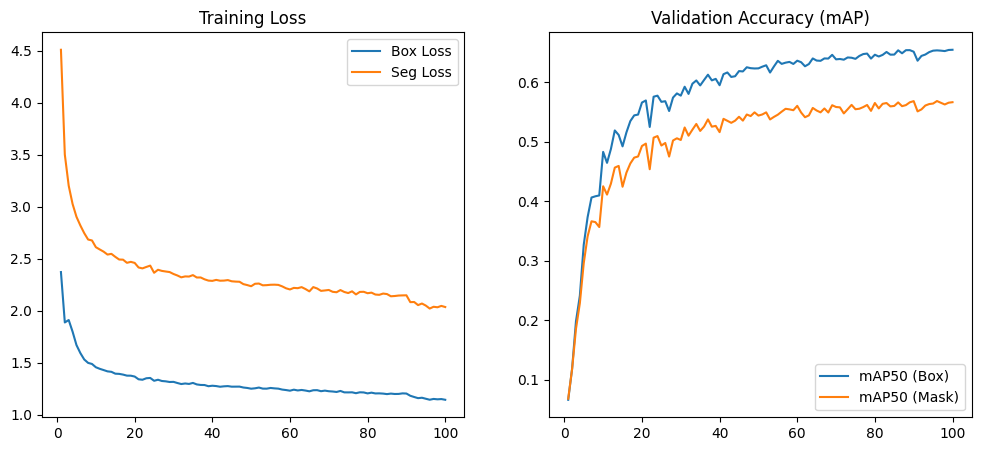

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Your verified path
actual_results_dir = './runs/segment/floorplan_results/sahi_baseline'
csv_path = os.path.join(actual_results_dir, 'results.csv')

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]

    plt.figure(figsize=(12, 5))
    
    # Plotting Segment and Box Loss
    plt.subplot(1, 2, 1)
    plt.plot(df['epoch'], df['train/box_loss'], label='Box Loss')
    plt.plot(df['epoch'], df['train/seg_loss'], label='Seg Loss')
    plt.title('Training Loss')
    plt.legend()

    # Plotting mAP
    plt.subplot(1, 2, 2)
    plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50 (Box)')
    plt.plot(df['epoch'], df['metrics/mAP50(M)'], label='mAP50 (Mask)')
    plt.title('Validation Accuracy (mAP)')
    plt.legend()
    
    plt.show()
else:
    print(f"Could not find results.csv at {csv_path}")

In [2]:
%pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 35.8 MB/s  0:00:00eta 0:00:01
Note: you may need to restart the kernel to use updated packages.



image 1/1 /home3/aechebykin_1/yolo_seg_data/images/val/high_quality_architectural_7606_.png: 448x640 68 walls, 2 doors, 1 kitchen, 1 livingroom, 2 bedrooms, 2 laundrys, 12 closets, 1 toilet, 1 sink, 373.9ms
Speed: 17.8ms preprocess, 373.9ms inference, 90.6ms postprocess per image at shape (1, 3, 448, 640)


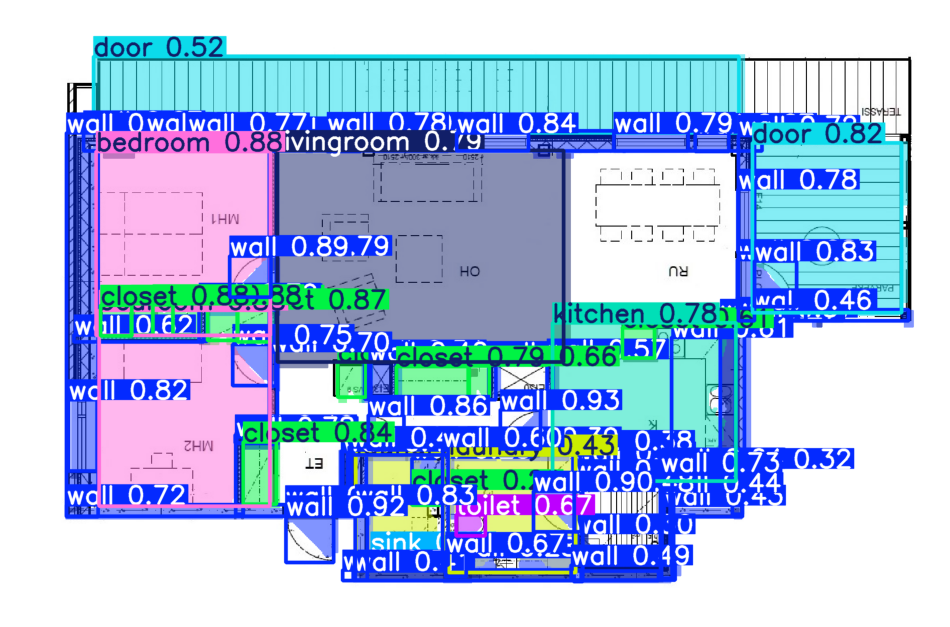

In [5]:
from ultralytics import YOLO
import cv2
import glob

best_model = './runs/segment/floorplan_results/sahi_baseline/weights/best.pt'
model = YOLO(best_model)

# Find a random test image
test_images = glob.glob('yolo_seg_data/images/val/*.png')

if test_images:
    results = model.predict(test_images[0], conf=0.25)
    
    # Show the result
    res_plotted = results[0].plot()
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()